<a href="https://colab.research.google.com/github/Sibuninja/ML_LAB_ASSIGNMENT/blob/ASSIGNMENT-1/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Experiment 1: Linear Regression and Regularization

**Objective:** To implement Linear Regression from scratch and using scikit-learn, and to study the effect of Ridge and Lasso regularization.

**Software / Tools Required:** Python 3.x, NumPy, Matplotlib, Scikit-learn (all pre-installed in Colab)


## Step 0: Install / Import Libraries
Colab already has these installed, but running this cell ensures everything is up to date.

In [1]:
!pip install -q numpy matplotlib scikit-learn

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline


## Step 1: Load the California Housing Dataset

In [2]:
data = fetch_california_housing()
X = data.data          # shape: (n_samples, 8 features)
y = data.target        # target: median house value (in $100,000s)
feature_names = data.feature_names

print(f"Number of samples : {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Feature names     : {feature_names}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features (important for Gradient Descent & Regularization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Number of samples : 20640
Number of features: 8
Feature names     : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## Step 2: Linear Regression from Scratch
### 2a. Normal Equation
$$\theta = (X^T X)^{-1} X^T y$$

In [3]:
def normal_equation(X, y):
    X_b = np.c_[np.ones((X.shape[0], 1)), X]  # add bias column (intercept)
    theta = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y
    return theta

def predict_normal(X, theta):
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    return X_b @ theta

theta_normal = normal_equation(X_train_scaled, y_train)
y_pred_normal = predict_normal(X_test_scaled, theta_normal)

mse_normal = mean_squared_error(y_test, y_pred_normal)
r2_normal = r2_score(y_test, y_pred_normal)

print(f"[Normal Equation]  Intercept: {theta_normal[0]:.4f}")
print(f"[Normal Equation]  MSE = {mse_normal:.4f}, R2 = {r2_normal:.4f}")


[Normal Equation]  Intercept: 2.0719
[Normal Equation]  MSE = 0.5559, R2 = 0.5758


### 2b. Gradient Descent

In [4]:
def gradient_descent(X, y, lr=0.05, n_epochs=1000):
    m = X.shape[0]
    X_b = np.c_[np.ones((m, 1)), X]     # add bias column
    n_features = X_b.shape[1]
    theta = np.zeros(n_features)        # initialize weights to zero
    cost_history = []

    for epoch in range(n_epochs):
        y_pred = X_b @ theta
        error = y_pred - y
        gradient = (2 / m) * (X_b.T @ error)
        theta -= lr * gradient

        cost = np.mean(error ** 2)      # MSE cost
        cost_history.append(cost)

    return theta, cost_history

theta_gd, cost_history = gradient_descent(
    X_train_scaled, y_train, lr=0.05, n_epochs=1000
)

y_pred_gd = predict_normal(X_test_scaled, theta_gd)
mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print(f"[Gradient Descent] Intercept: {theta_gd[0]:.4f}")
print(f"[Gradient Descent] MSE = {mse_gd:.4f}, R2 = {r2_gd:.4f}")


[Gradient Descent] Intercept: 2.0719
[Gradient Descent] MSE = 0.5560, R2 = 0.5757


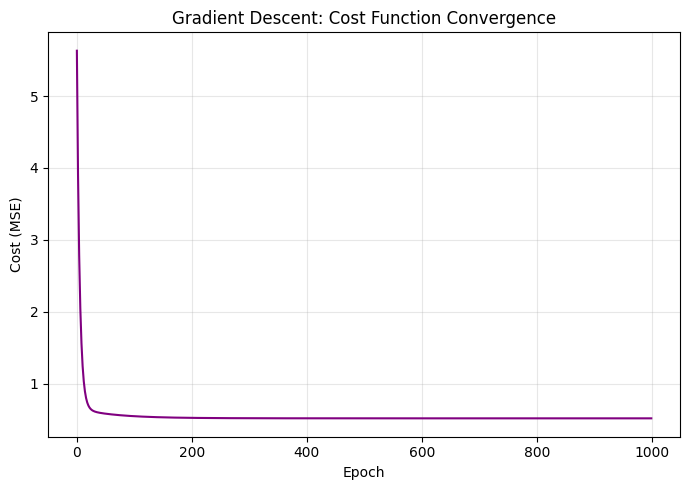

In [5]:
# Plot cost function convergence (confirms Gradient Descent is working)
plt.figure(figsize=(7, 5))
plt.plot(range(len(cost_history)), cost_history, color="purple")
plt.xlabel("Epoch")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent: Cost Function Convergence")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Step 3: Train using sklearn's LinearRegression

In [6]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred_lr = lin_reg.predict(X_test_scaled)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"[sklearn LinearRegression] MSE = {mse_lr:.4f}, R2 = {r2_lr:.4f}")


[sklearn LinearRegression] MSE = 0.5559, R2 = 0.5758


## Step 4: Ridge and Lasso Regularization

In [7]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"[Ridge Regression] MSE = {mse_ridge:.4f}, R2 = {r2_ridge:.4f}")
print(f"[Lasso Regression] MSE = {mse_lasso:.4f}, R2 = {r2_lasso:.4f}")

print("\nModel Comparison Summary:")
print(f"{'Model':<25}{'MSE':<12}{'R2 Score':<12}")
print("-" * 49)
print(f"{'Normal Equation':<25}{mse_normal:<12.4f}{r2_normal:<12.4f}")
print(f"{'Gradient Descent':<25}{mse_gd:<12.4f}{r2_gd:<12.4f}")
print(f"{'sklearn Linear Reg.':<25}{mse_lr:<12.4f}{r2_lr:<12.4f}")
print(f"{'Ridge Regression':<25}{mse_ridge:<12.4f}{r2_ridge:<12.4f}")
print(f"{'Lasso Regression':<25}{mse_lasso:<12.4f}{r2_lasso:<12.4f}")


[Ridge Regression] MSE = 0.5559, R2 = 0.5758
[Lasso Regression] MSE = 0.5483, R2 = 0.5816

Model Comparison Summary:
Model                    MSE         R2 Score    
-------------------------------------------------
Normal Equation          0.5559      0.5758      
Gradient Descent         0.5560      0.5757      
sklearn Linear Reg.      0.5559      0.5758      
Ridge Regression         0.5559      0.5758      
Lasso Regression         0.5483      0.5816      


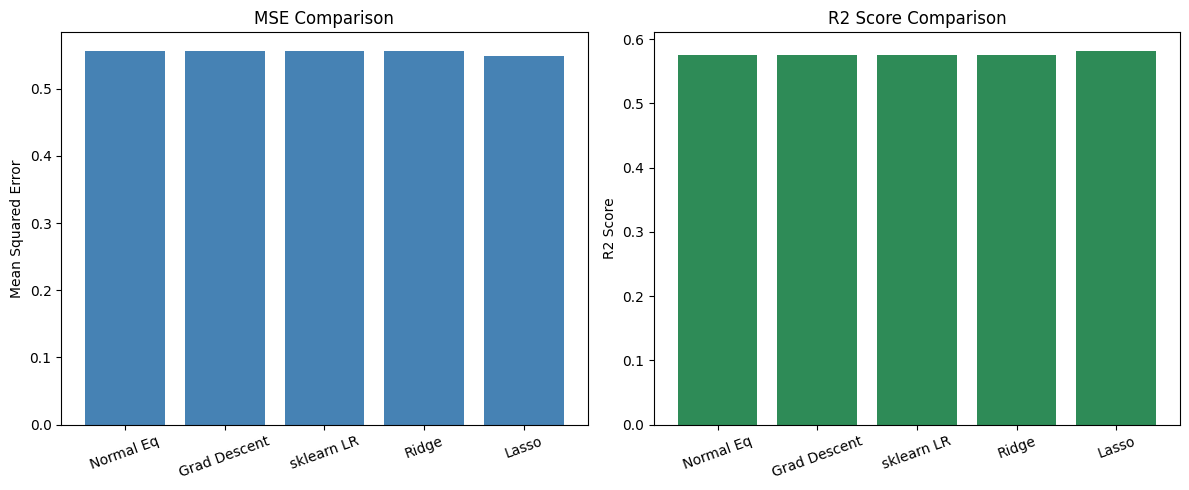

In [8]:
# Bar chart comparing MSE and R2 across models
models = ["Normal Eq", "Grad Descent", "sklearn LR", "Ridge", "Lasso"]
mse_scores = [mse_normal, mse_gd, mse_lr, mse_ridge, mse_lasso]
r2_scores = [r2_normal, r2_gd, r2_lr, r2_ridge, r2_lasso]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(models, mse_scores, color="steelblue")
axes[0].set_title("MSE Comparison")
axes[0].set_ylabel("Mean Squared Error")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(models, r2_scores, color="seagreen")
axes[1].set_title("R2 Score Comparison")
axes[1].set_ylabel("R2 Score")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## Step 5: Regression Curve — Predicted vs Actual Values

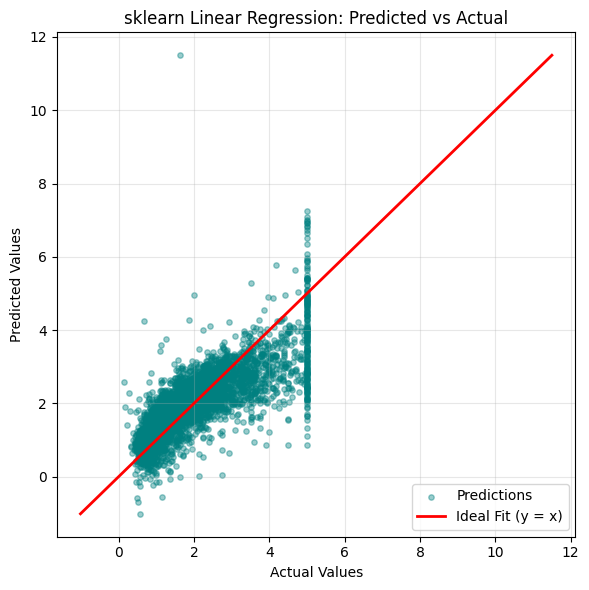

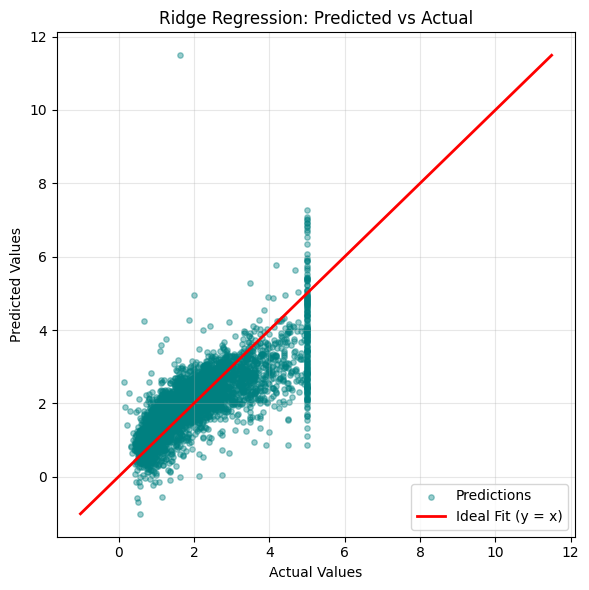

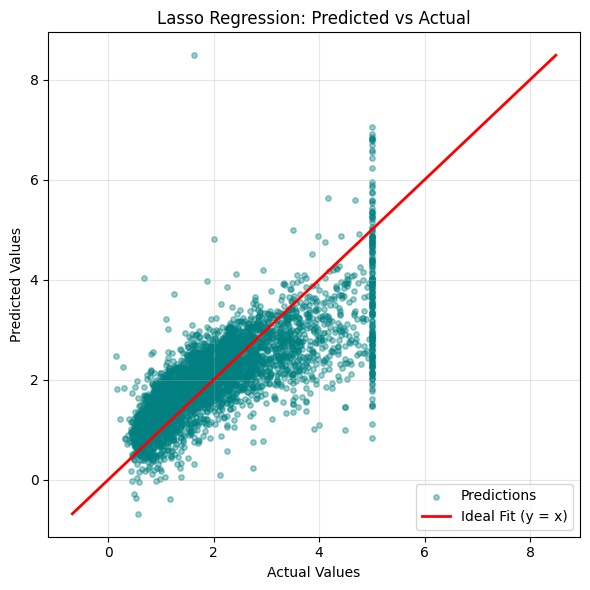

In [9]:
def plot_predicted_vs_actual(y_true, y_pred, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.4, s=15, color="teal", label="Predictions")
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.plot(lims, lims, color="red", linewidth=2, label="Ideal Fit (y = x)")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_predicted_vs_actual(y_test, y_pred_lr, "sklearn Linear Regression: Predicted vs Actual")
plot_predicted_vs_actual(y_test, y_pred_ridge, "Ridge Regression: Predicted vs Actual")
plot_predicted_vs_actual(y_test, y_pred_lasso, "Lasso Regression: Predicted vs Actual")


### Single-feature Regression Line (MedInc vs House Value)

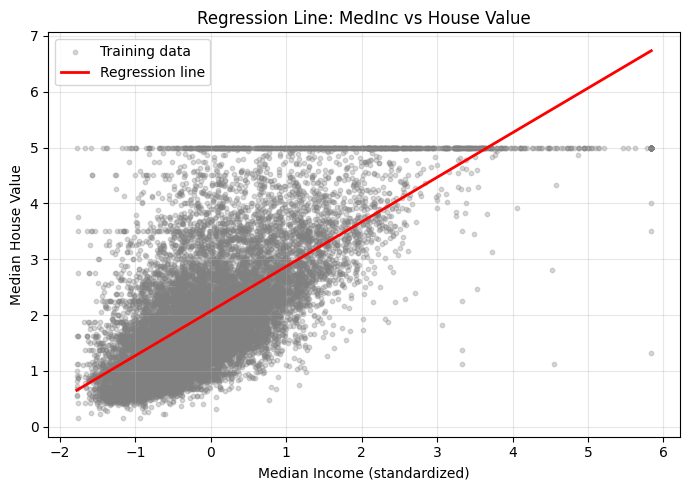


All steps completed successfully.


In [10]:
feature_idx = list(feature_names).index("MedInc")
X_single = X_train_scaled[:, feature_idx].reshape(-1, 1)

single_reg = LinearRegression()
single_reg.fit(X_single, y_train)

X_range = np.linspace(X_single.min(), X_single.max(), 100).reshape(-1, 1)
y_range_pred = single_reg.predict(X_range)

plt.figure(figsize=(7, 5))
plt.scatter(X_single, y_train, alpha=0.3, s=10, color="gray", label="Training data")
plt.plot(X_range, y_range_pred, color="red", linewidth=2, label="Regression line")
plt.xlabel("Median Income (standardized)")
plt.ylabel("Median House Value")
plt.title("Regression Line: MedInc vs House Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nAll steps completed successfully.")
